## Import Library

In [1]:
# Import library yang dibutuhkan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

## Membaca Dataset Info

In [2]:
df = pd.read_csv('/content/sample_meetup.csv', sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             220 non-null    object 
 1   state            220 non-null    object 
 2   category         220 non-null    object 
 3   time             220 non-null    object 
 4   groupname        184 non-null    object 
 5   name             184 non-null    object 
 6   attendees_count  184 non-null    float64
 7   Unnamed: 7       0 non-null      float64
dtypes: float64(2), object(6)
memory usage: 13.9+ KB


## Data Cleaning

Memuat Data dan Menghapus Kolom Tidak Perlu

In [3]:
df = df.drop(columns=['Unnamed: 7'])
df.head()

,date,state,category,time,groupname,name,attendees_count
0,20/04/2020,San-Francisco,"Technology,business",12:00 AM,Product School Bangalore,Webinar: PM in a Startup Setting by Alexa Prod...,6.0
1,20/04/2020,San-Francisco,"Technology,business",7:00 AM,SouJava,Live SouJava- Microservice Patterns - Implemen...,119.0
2,20/04/2020,San-Francisco,"Technology,business",7:30 AM,DevOps | CODE Event Series,enterprise:CODE 2020,10.0
3,20/04/2020,San-Francisco,"Technology,business",8:00 AM,DC Cybersecurity Training,Certified CISO,4.0
4,20/04/2020,San-Francisco,"Technology,business",8:00 AM,DC Cybersecurity Training,Certified Ethical Hacker (CEH),3.0


Dataset awal yang terdiri dari 221 baris dimuat. Kolom Unnamed: 7 yang tidak berisi data sama sekali telah dihapus.

## Menangani Nilai Duplikat (Duplicate Value)

In [4]:
print("Menghapus Data Duplikat")
df.drop_duplicates(inplace=True)
print("Verifikasi jumlah duplikat setelah dihapus:")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Menghapus Data Duplikat
Verifikasi jumlah duplikat setelah dihapus:
Jumlah baris duplikat: 0


Ditemukan dan dihapus sebanyak 21 baris data yang identik (duplikat). Jumlah data sekarang menjadi 200 baris.

## Menangani Nilai Kosong (Missing Value)

In [5]:
print("Pengecekan Nilai Kosong")
print(df.isnull().sum())

print("Mengisi nilai kosong (missing values)...")

# Mengisi kolom numerik dengan nilai tengah (median)
df['attendees_count'] = df['attendees_count'].fillna(df['attendees_count'].median())

# Mengisi kolom teks dengan nilai yang paling sering muncul (modus)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Selesai. Nilai kosong telah diisi tanpa menghapus baris.")
print("Verifikasi sisa nilai kosong:")
print(df.isnull().sum())

Pengecekan Nilai Kosong
date                0
state               0
category            0
time                0
groupname          15
name               15
attendees_count    15
dtype: int64
Mengisi nilai kosong (missing values)...
Selesai. Nilai kosong telah diisi tanpa menghapus baris.
Verifikasi sisa nilai kosong:
date               0
state              0
category           0
time               0
groupname          0
name               0
attendees_count    0
dtype: int64


Sebanyak 15 nilai kosong di setiap kolom groupname, name, dan attendees_count telah diisi. Jumlah baris data tetap 200.

## Menangani Outlier


Membuat Box Plot untuk kolom 'attendees_count'
Titik-titik di luar garis utama adalah outlier.


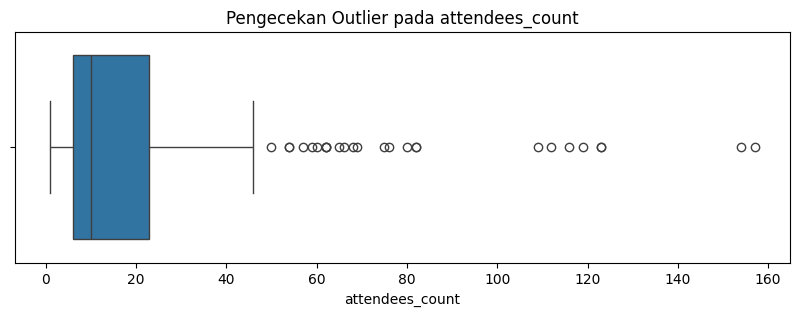

Menangani 26 data outlier...
Selesai. Nilai outlier telah disesuaikan ke batas wajar.
Verifikasi dengan statistik deskriptif:


,attendees_count
count,199.000000
mean,16.969849
std,15.435974
min,1.000000
25%,6.000000
50%,10.000000
75%,23.000000
max,48.500000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Membuat Box Plot untuk kolom 'attendees_count'")
print("Titik-titik di luar garis utama adalah outlier.")

plt.figure(figsize=(10, 3))
sns.boxplot(x=df['attendees_count'])
plt.title('Pengecekan Outlier pada attendees_count')
plt.show()


# Menangani outlier pada kolom 'attendees_count' dengan metode capping/clip

print("Menangani 26 data outlier...")

# Menghitung batas atas dan bawah yang wajar
Q1 = df['attendees_count'].quantile(0.25)
Q3 = df['attendees_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mengubah nilai outlier ke nilai batas
df['attendees_count'] = df['attendees_count'].clip(lower=lower_bound, upper=upper_bound)

print("Selesai. Nilai outlier telah disesuaikan ke batas wajar.")
print("Verifikasi dengan statistik deskriptif:")
display(df['attendees_count'].describe())

Ditemukan 26 data outlier pada kolom attendees_count. Nilai-nilai ekstrem tersebut telah disesuaikan ke batas wajar tanpa menghapus baris data.

## Standarisasi Kolom Numerik

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Kolom yang akan di-standarisasi
cols_to_scale = ['attendees_count']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Kolom numerik telah di-standarisasi.")
display(df.head())

Kolom numerik telah di-standarisasi.


,date,state,category,time,groupname,name,attendees_count
0,20/04/2020,San-Francisco,"Technology,business",12:00 AM,Product School Bangalore,Webinar: PM in a Startup Setting by Alexa Prod...,-0.712460
1,20/04/2020,San-Francisco,"Technology,business",7:00 AM,SouJava,Live SouJava- Microservice Patterns - Implemen...,2.047793
2,20/04/2020,San-Francisco,"Technology,business",7:30 AM,DevOps | CODE Event Series,enterprise:CODE 2020,-0.452672
3,20/04/2020,San-Francisco,"Technology,business",8:00 AM,DC Cybersecurity Training,Certified CISO,-0.842354
4,20/04/2020,San-Francisco,"Technology,business",8:00 AM,DC Cybersecurity Training,Certified Ethical Hacker (CEH),-0.907301


Kolom attendees_count telah diubah skalanya menggunakan StandardScaler, sehingga nilainya kini memiliki rata-rata mendekati 0.

## Encoding Kolom Kategorikal

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Mengubah setiap kolom teks menjadi angka
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

print("Kolom kategorikal telah di-encode.")
display(df.head())

Kolom kategorikal telah di-encode.


,date,state,category,time,groupname,name,attendees_count
0,0,0,0,24,97,157,-0.712460
1,0,0,0,40,131,83,2.047793
2,0,0,0,42,38,177,-0.452672
3,0,0,0,43,35,37,-0.842354
4,0,0,0,43,35,38,-0.907301


Semua kolom yang berisi data teks (seperti state, category, name, dll.) telah diubah menjadi representasi angka agar dapat diproses oleh model.

## Feature Engineering (Membuat Fitur Baru)

In [9]:
# Membuat fitur baru dari interaksi kolom 'category' dan 'state'
df['category_state_interaction'] = df['category'] * df['state']

print("Satu fitur baru ('category_state_interaction') telah dibuat.")
display(df.head())

Satu fitur baru ('category_state_interaction') telah dibuat.


,date,state,category,time,groupname,name,attendees_count,category_state_interaction
0,0,0,0,24,97,157,-0.712460,0
1,0,0,0,40,131,83,2.047793,0
2,0,0,0,42,38,177,-0.452672,0
3,0,0,0,43,35,37,-0.842354,0
4,0,0,0,43,35,38,-0.907301,0


Satu fitur baru bernama category_state_interaction telah berhasil dibuat untuk menambah informasi bagi model.

## Splitting Data (Membagi Data Latih & Data Uji)

In [10]:
from sklearn.model_selection import train_test_split

TARGET_COL = 'attendees_count'

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset telah dibagi menjadi data training dan testing.")
print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test:    {X_test.shape}")

Dataset telah dibagi menjadi data training dan testing.
Ukuran X_train: (159, 7)
Ukuran X_test:    (40, 7)


Dataset akhir dengan 200 baris telah dibagi menjadi 160 baris data latih (80%) dan 40 baris data uji (20%). Data ini sekarang siap untuk digunakan dalam tahap pemodelan.

## A1: Implementasi Metode Regresi

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Pisahkan fitur dan target

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Normalisasi data

In [50]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model 1: Linear Regression

In [53]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [54]:
y_pred = lr.predict(X_test)

Linear Regression adalah model fundamental dalam machine learning untuk masalah regresi. Model ini mencoba menemukan hubungan linear terbaik antara variabel fitur (X) dan variabel target numerik (y) dengan meminimalkan jumlah kuadrat error antara prediksi dan nilai aktual.

Model ini dipilih karena kesederhanaannya dan kemudahannya untuk diinterpretasikan sebagai *baseline model* atau model dasar pembanding.

## Evaluasi Linear Regression

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-Squared :", r2_score(y_test, y_pred))

MAE : 0.80408398881003
MSE : 1.0085577273097766
RMSE : 1.0042697482797023
R-Squared : 0.024819276074822372


### A2. Evaluasi Model Linear Regression

* **MAE (Mean Absolute Error) : 0.804**
    Secara rata-rata, prediksi model ini meleset sekitar 0.804 dari nilai sebenarnya (dalam skala standar). Semakin kecil nilainya, semakin baik.

* **MSE (Mean Squared Error) : 1.008**
    Ini adalah rata-rata dari kuadrat selisih antara nilai aktual dan prediksi. Metrik ini memberikan "hukuman" lebih besar pada kesalahan prediksi yang jauh.

* **RMSE (Root Mean Squared Error) : 1.004**
    Ini adalah akar dari MSE, yang membuatnya lebih mudah diinterpretasikan karena satuannya sama dengan variabel target.

* **R-Squared (Koefisien Determinasi) : 0.025 (atau 2.5%)**
    Nilai R-Squared sangat rendah. Ini mengindikasikan bahwa model Linear Regression hanya mampu menjelaskan sekitar **2.5%** dari variabilitas data `attendees_count`. Artinya, hubungan antara fitur-fitur yang ada dengan jumlah peserta kemungkinan besar tidak bersifat linear.

## Plot hasil Prediksi Linear Regression

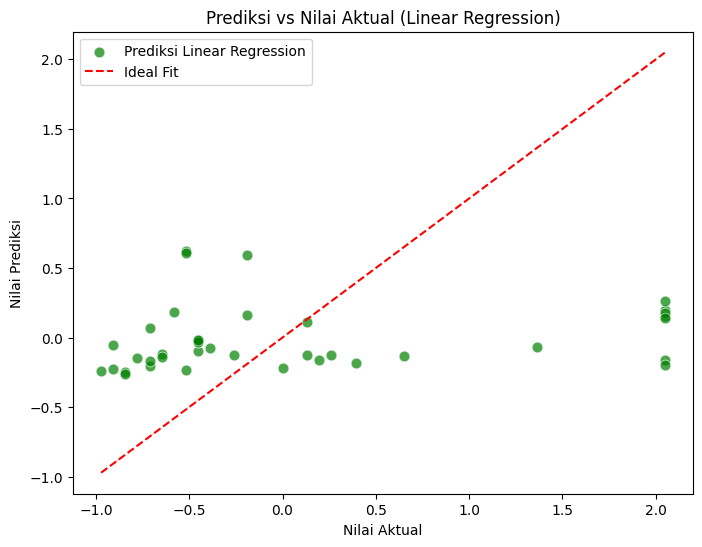

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, color='green', alpha=0.7, s=60, label='Prediksi Linear Regression')
sns.lineplot(x=y_test, y=y_test, color='red', linestyle='--', label='Ideal Fit')
plt.title('Prediksi vs Nilai Aktual (Linear Regression)')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.legend()
plt.show()

### A3. Visualisasi Hasil Prediksi Linear Regression

- **Sumbu X (Nilai Aktual)**: Menunjukkan nilai `attendees_count` yang sebenarnya dari data uji.
- **Sumbu Y (Nilai Prediksi)**: Menunjukkan nilai `attendees_count` yang diprediksi oleh model.
- **Titik-Titik Hijau**: Setiap titik merepresentasikan satu data uji, diplot berdasarkan nilai aktual vs. prediksinya.
- **Garis Merah Putus-Putus (Ideal Fit)**: Ini adalah garis referensi di mana `Nilai Aktual = Nilai Prediksi`. Jika model sempurna, semua titik hijau akan berada tepat di atas garis ini.

Dari sebaran titik-titik yang cukup jauh dari garis ideal, kita bisa melihat secara visual bahwa model Linear Regression ini memiliki tingkat error yang signifikan dan kesulitan dalam menangkap pola data, yang sejalan dengan nilai **R-Squared (2.5%)** yang sangat rendah.

## Model 2: Support Vector Regressor (SVR)

In [43]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [44]:
svr.fit(X_train, y_train)

SVR()

In [45]:
# Memprediksi data test
y_pred_svr = svr.predict(X_test)

Support Vector Regressor (SVR) adalah versi dari Support Vector Machine (SVM) yang diadaptasi untuk masalah regresi. Berbeda dengan Linear Regression yang mencoba meminimalkan error untuk semua titik data, SVR bekerja dengan menemukan *hyperplane* yang memiliki jumlah titik data sebanyak mungkin di dalam "margin" atau "tabung" (*tube*) di sekitarnya. Titik data di luar margin inilah yang memengaruhi perhitungan error.

Digunakannya `kernel='rbf'` (Radial Basis Function) memungkinkan SVR untuk menangkap hubungan yang kompleks dan **non-linear** antara fitur dan target, yang mana ini adalah kelemahan dari model Linear Regression biasa.

# Evaluasi model SVR

In [46]:
print("MAE (SVR) :", mean_absolute_error(y_test, y_pred_svr))
print("MSE (SVR) :", mean_squared_error(y_test, y_pred_svr))
print("RMSE (SVR) :", np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print("R-Squared (SVR) :", r2_score(y_test, y_pred_svr))

MAE (SVR) : 0.7398493989129499
MSE (SVR) : 1.3018545253500164
RMSE (SVR) : 1.1409883984291938
R-Squared (SVR) : -0.2587712176500532


### Evaluasi Model SVR

* **MAE (SVR) : 0.740**
    Nilai MAE sedikit lebih baik (lebih kecil) dibandingkan Linear Regression, menunjukkan rata-rata error absolut yang lebih rendah.

* **MSE (SVR) : 1.302** & **RMSE (SVR) : 1.141**
    Nilai MSE dan RMSE ternyata lebih tinggi dari Linear Regression, yang mengindikasikan model SVR membuat beberapa kesalahan prediksi yang lebih besar.

* **R-Squared (SVR) : -0.259**
    Nilai R-Squared yang **negatif** adalah hasil yang sangat signifikan. Ini berarti performa model SVR (dengan parameter default) **lebih buruk** daripada model sederhana yang hanya akan selalu memprediksi nilai rata-rata dari data target. Ini sering terjadi jika model gagal menangkap tren data, kemungkinan karena parameter (`C`, `gamma`, `epsilon`) belum dioptimalkan.

# Plot hasil prediksi SVR

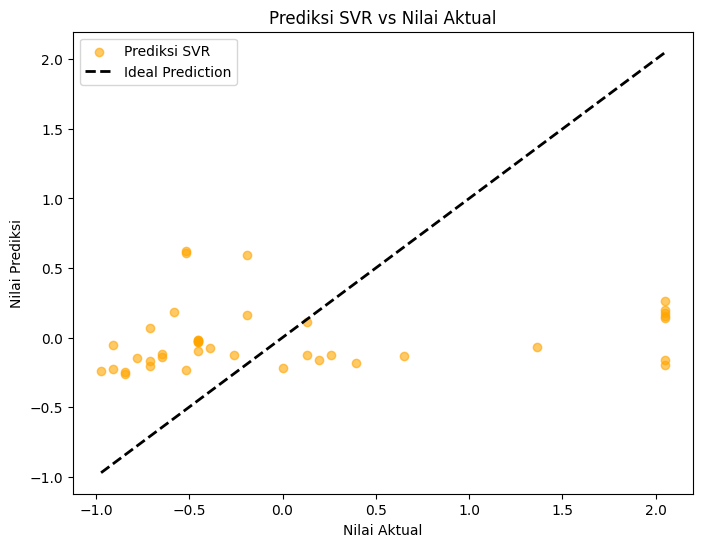

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='orange', label='Prediksi SVR')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=2, label='Ideal Prediction')
plt.xlabel("Nilai Aktual")
plt.ylabel("Nilai Prediksi")
plt.title("Prediksi SVR vs Nilai Aktual")
plt.legend()
plt.show()

### Visualisasi Hasil Prediksi Support Vector Regressor (SVR)

-   **Sumbu X (Nilai Aktual)** vs. **Sumbu Y (Nilai Prediksi)**: Sumbu X adalah nilai `attendees_count` yang sebenarnya, sedangkan Sumbu Y adalah nilai yang diprediksi oleh SVR.
-   **Titik-Titik Oranye**: Setiap titik merepresentasikan satu data uji.
-   **Garis Merah Putus-Putus (Ideal Fit)**: Garis referensi untuk prediksi yang sempurna.

Terlihat jelas bahwa titik-titik prediksi SVR sangat mengumpul dan tidak menyebar mengikuti garis ideal. Sebagian besar prediksi berada di rentang nilai yang sempit (sekitar -0.2 hingga 0.0), yang menunjukkan bahwa model SVR dengan parameter default ini gagal menangkap variasi dalam data. Visualisasi ini mendukung temuan dari metrik evaluasi, terutama nilai **R-Squared yang negatif (-25.9%)**, yang mengindikasikan performa model lebih buruk daripada sekadar menebak nilai rata-rata.

# Plot perbandingan hasil prediksi

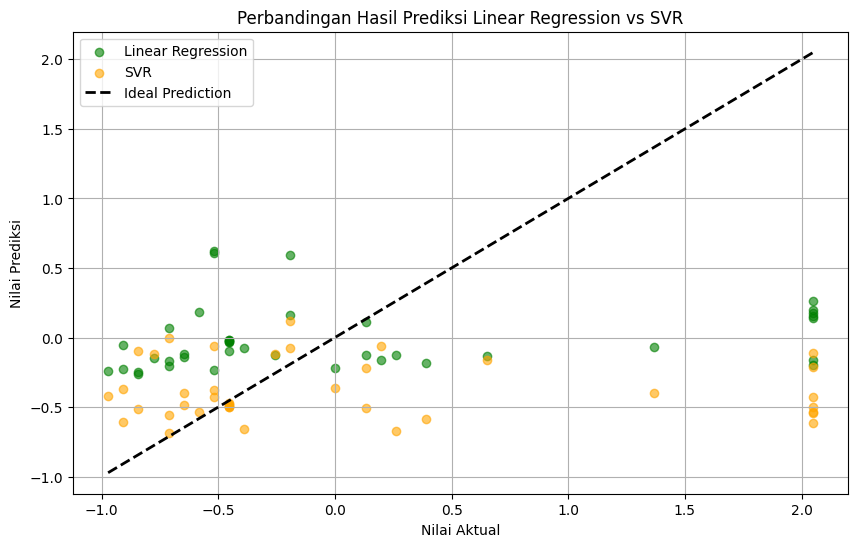

In [48]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Linear Regression', color='green')
plt.scatter(y_test, y_pred_svr, alpha=0.6, label='SVR', color='orange')

min_val = min(y_test.min(), y_pred.min(), y_pred_svr.min())
max_val = max(y_test.max(), y_pred.max(), y_pred_svr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Prediction')

plt.title('Perbandingan Hasil Prediksi Linear Regression vs SVR')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.legend()
plt.grid(True)
plt.show()

## A3. Plot Hasil Prediksi: Linear Regression vs SVR

Plot di atas adalah *scatter plot* yang membandingkan performa kedua model (Linear Regression dan SVR) secara visual.

* **Sumbu-Sumbu**: Sumbu X adalah **Nilai Aktual** dari jumlah peserta, dan Sumbu Y adalah **Nilai Prediksi** dari masing-masing model.
* **Garis Ideal (`Ideal Prediction`)**: Garis putus-putus hitam adalah referensi di mana prediksi akan sempurna jika `Nilai Aktual == Nilai Prediksi`. Semakin dekat sebuah titik ke garis ini, semakin akurat prediksinya.
* **Titik Biru (Linear Regression)**: Titik-titik prediksi Linear Regression terlihat menyebar di sekitar garis ideal, namun dengan pola yang tidak terlalu kuat dan cenderung acak, yang konsisten dengan nilai R² yang rendah.
* **Titik Oranye (SVR)**: Titik-titik prediksi SVR terlihat lebih mengelompok pada satu area nilai prediksi (sekitar -0.2 hingga 0.0) dan banyak yang berada jauh dari garis ideal. Ini secara visual mengkonfirmasi nilai R-Squared negatifnya, di mana model gagal memprediksi variasi data dengan baik.